# Nghe lại các bước xử lý âm thanh

Notebook này cho phép bạn:

- Nghe **tín hiệu gốc** (raw)
- Nghe sau từng bước tiền xử lý: **normalize**, **trim_silence**, **pad_or_crop**
- Nghe sau khi **lọc FIR bandpass 300–3400 Hz**

Điền đường dẫn đến file `.wav` bạn muốn thử và chạy lần lượt các cell bên dưới.


In [22]:
import sys, os
from IPython.display import Audio

# Thêm đường dẫn project root để import được src.* khi chạy từ thư mục notebooks/
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src import preprocess
from src import filter as filter_mod
from src.preemphasis import pre_emphasize


In [23]:
# Đường dẫn tới file WAV bạn muốn nghe thử
# Ví dụ: "../data/raw/speaker1_001.wav"
audio_path = "../data/test.mp3"  # TODO: sửa lại cho đúng với dữ liệu của bạn
audio_path


'../data/test.mp3'

In [24]:
# 1) Tải và nghe tín hiệu gốc (raw)
y_raw, sr = preprocess.load_audio(audio_path, sr=16000)
print(f"Raw length: {len(y_raw)/sr:.2f} s, sr = {sr} Hz")
Audio(y_raw, rate=sr)


Raw length: 23.07 s, sr = 16000 Hz


In [25]:
# 2) Sau bước normalize
y_norm = preprocess.normalize(y_raw)
print(f"Normalize: peak = {y_norm.max():.3f}, min = {y_norm.min():.3f}")
Audio(y_norm, rate=sr)


Normalize: peak = 0.894, min = -1.000


In [26]:
# 3) Sau bước trim_silence
y_trim = preprocess.trim_silence(y_norm, top_db=20)
print(f"Trimmed length: {len(y_trim)/sr:.2f} s")
Audio(y_trim, rate=sr)


Trimmed length: 22.78 s


In [27]:
# 4) Sau bước pad_or_crop (tín hiệu cố định 3 giây = 48000 mẫu)
y_fixed = preprocess.pad_or_crop(y_trim, target_len=48000)
print(f"Fixed length: {len(y_fixed)} samples, {len(y_fixed)/sr:.2f} s")
Audio(y_fixed, rate=sr)


Fixed length: 48000 samples, 3.00 s


In [30]:
# 5) Sau khi lọc FIR bandpass 300–3400 Hz
coeffs = filter_mod.design_fir(lowcut=80, highcut=3400, sr=sr, numtaps=101)
y_filt = filter_mod.apply_filter(y_fixed, coeffs)
print(f"Filtered length: {len(y_filt)} samples, {len(y_filt)/sr:.2f} s")
Audio(y_filt, rate=sr)


Filtered length: 48000 samples, 3.00 s


In [31]:
# Áp dụng pre-emphasis sau khi lọc FIR
alpha = 0.97

# y_filt và sr được tạo ở bước 5
y_pre = pre_emphasize(y_filt, alpha=alpha)

print(f"Pre-emphasized length: {len(y_pre)} samples, {len(y_pre)/sr:.2f} s")
print(f"alpha = {alpha}")

print("Nghe tín hiệu sau pre-emphasis:")
Audio(y_pre, rate=sr)

Pre-emphasized length: 48000 samples, 3.00 s
alpha = 0.97
Nghe tín hiệu sau pre-emphasis:


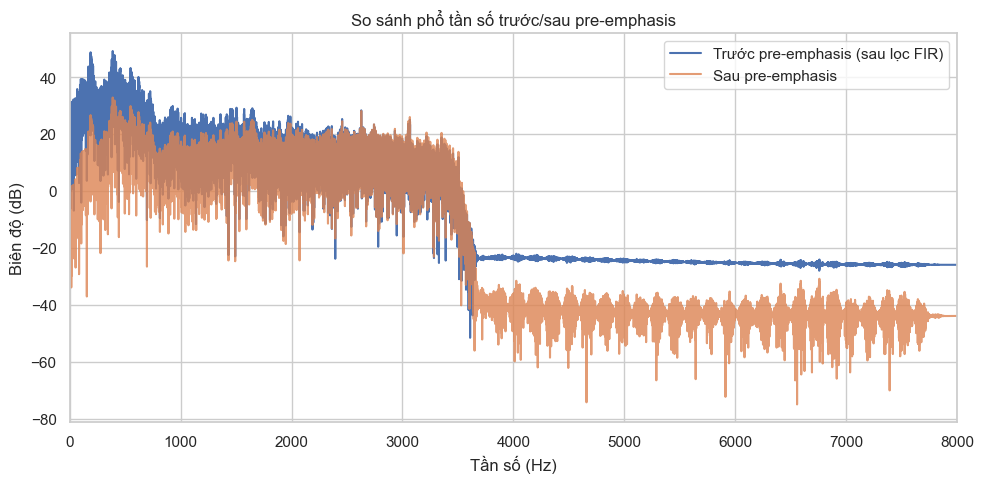

In [32]:
# Vẽ phổ tần số trước và sau pre-emphasis
import numpy as np
import matplotlib.pyplot as plt

# Giả sử y_filt và y_pre, sr đã có từ các bước trước

# Dùng FFT 1 phía (real FFT)
Y_filt = np.fft.rfft(y_filt)
Y_pre = np.fft.rfft(y_pre)

freqs = np.fft.rfftfreq(len(y_filt), d=1.0 / sr)

mag_filt_db = 20 * np.log10(np.abs(Y_filt) + 1e-10)
mag_pre_db = 20 * np.log10(np.abs(Y_pre) + 1e-10)

plt.figure(figsize=(10, 5))
plt.plot(freqs, mag_filt_db, label="Trước pre-emphasis (sau lọc FIR)")
plt.plot(freqs, mag_pre_db, label="Sau pre-emphasis", alpha=0.8)
plt.xlim(0, sr / 2)
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ (dB)")
plt.title("So sánh phổ tần số trước/sau pre-emphasis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import librosa
import pandas as pd

# Hàm tiện ích tính một số thông số cơ bản

def audio_stats(y, sr):
    if y is None:
        return {"duration_s": np.nan, "rms": np.nan, "peak": np.nan,
                "zcr": np.nan, "spectral_centroid_Hz": np.nan}
    duration = len(y) / sr
    rms = float(np.sqrt(np.mean(y ** 2))) if len(y) > 0 else np.nan
    peak = float(np.max(np.abs(y))) if len(y) > 0 else np.nan
    zcr = float(np.mean(librosa.feature.zero_crossing_rate(y))) if len(y) > 0 else np.nan
    if len(y) > 0:
        sc = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid = float(np.mean(sc))
    else:
        spectral_centroid = np.nan
    return {
        "duration_s": duration,
        "rms": rms,
        "peak": peak,
        "zcr": zcr,
        "spectral_centroid_Hz": spectral_centroid,
    }

# Thu thập các tín hiệu ở từng giai đoạn (giả sử bạn đã chạy các cell trước)

stages = [
    ("raw",       locals().get("y_raw")),
    ("normalize", locals().get("y_norm")),
    ("trim",      locals().get("y_trim")),
    ("pad/crop",  locals().get("y_fixed")),
    ("filtered",  locals().get("y_filt")),
]

rows = []
for name, sig in stages:
    stats = audio_stats(sig, sr)
    stats["stage"] = name
    rows.append(stats)

# Tạo bảng so sánh

df_stats = pd.DataFrame(rows)[["stage", "duration_s", "rms", "peak", "zcr", "spectral_centroid_Hz"]]
df_stats

,stage,duration_s,rms,peak,zcr,spectral_centroid_Hz
0,raw,23.066125,0.012084,0.084015,0.093734,1441.128589
1,normalize,23.066125,0.143831,1.000000,0.093794,1441.128589
2,trim,22.778125,0.144737,1.000000,0.093354,1436.087647
3,pad/crop,3.000000,0.084359,0.417964,0.088841,1453.054471
4,filtered,3.000000,0.053662,0.282353,0.098513,1129.667700


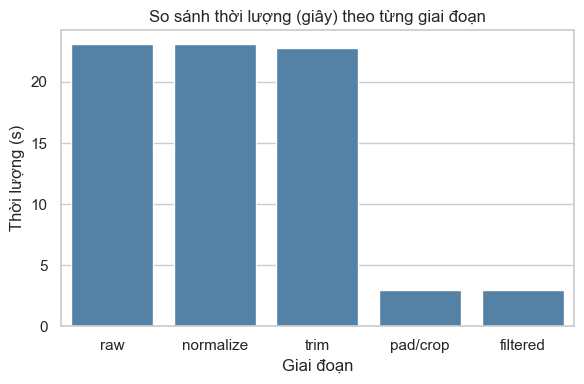

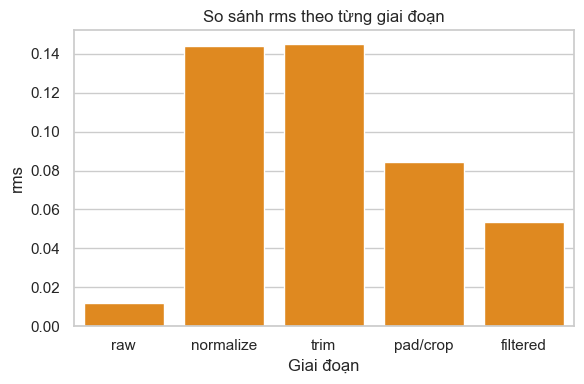

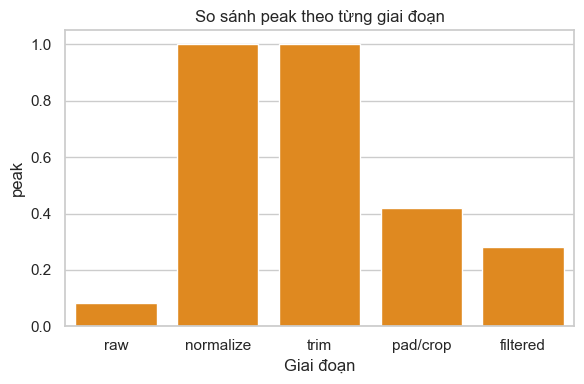

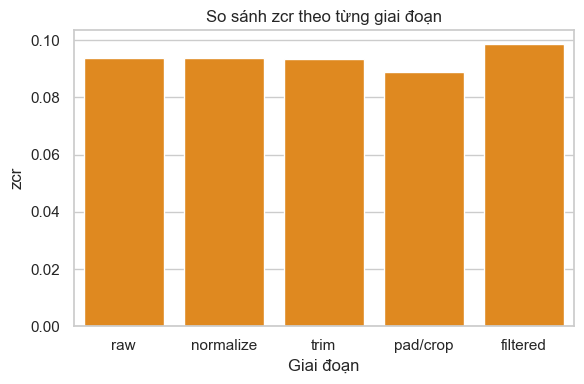

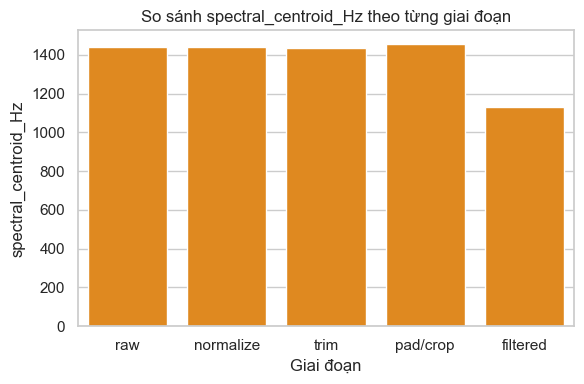

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo đã có df_stats từ cell trước
assert 'df_stats' in globals(), "Hãy chạy cell tạo df_stats trước khi vẽ chart."

sns.set(style="whitegrid")

# 1) Biểu đồ duration theo từng giai đoạn
plt.figure(figsize=(6, 4))
sns.barplot(data=df_stats, x="stage", y="duration_s", color="steelblue")
plt.title("So sánh thời lượng (giây) theo từng giai đoạn")
plt.xlabel("Giai đoạn")
plt.ylabel("Thời lượng (s)")
plt.tight_layout()
plt.show()

# 2) Biểu đồ các thông số khác (rms, peak, zcr, spectral_centroid_Hz)
metrics = ["rms", "peak", "zcr", "spectral_centroid_Hz"]

for m in metrics:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df_stats, x="stage", y=m, color="darkorange")
    plt.title(f"So sánh {m} theo từng giai đoạn")
    plt.xlabel("Giai đoạn")
    plt.ylabel(m)
    plt.tight_layout()
    plt.show()